In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
import pandas as pd
file_path = "C:/Users/VIKASH CHOWDHARY/Desktop/Datafile.csv"
df = pd.read_csv(file_path)
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  


In [13]:
print(df.head())
print(df.info())
print(df.describe())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639

In [14]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


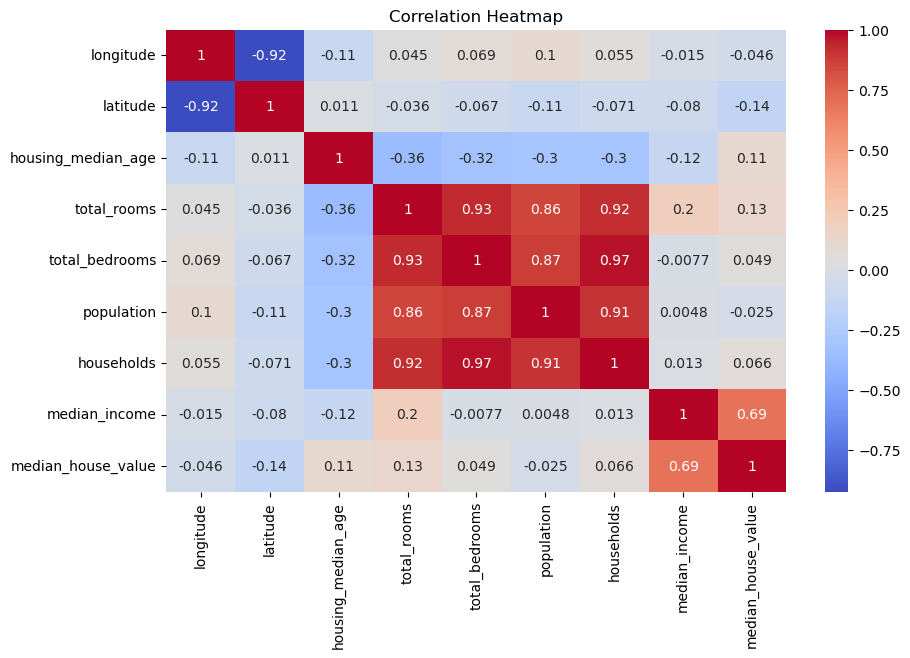

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

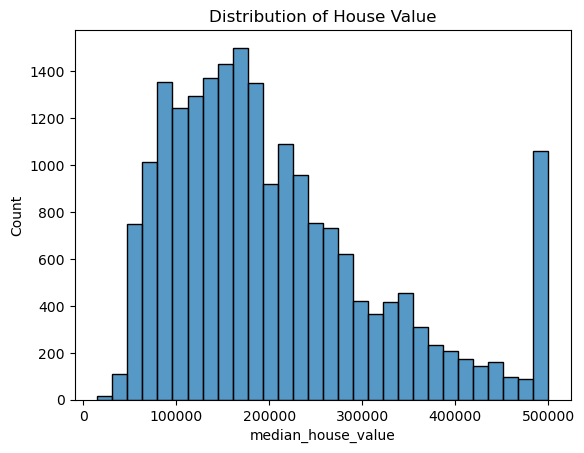

In [24]:
sns.histplot(df['median_house_value'], bins=30)
plt.title("Distribution of House Value")
plt.show()

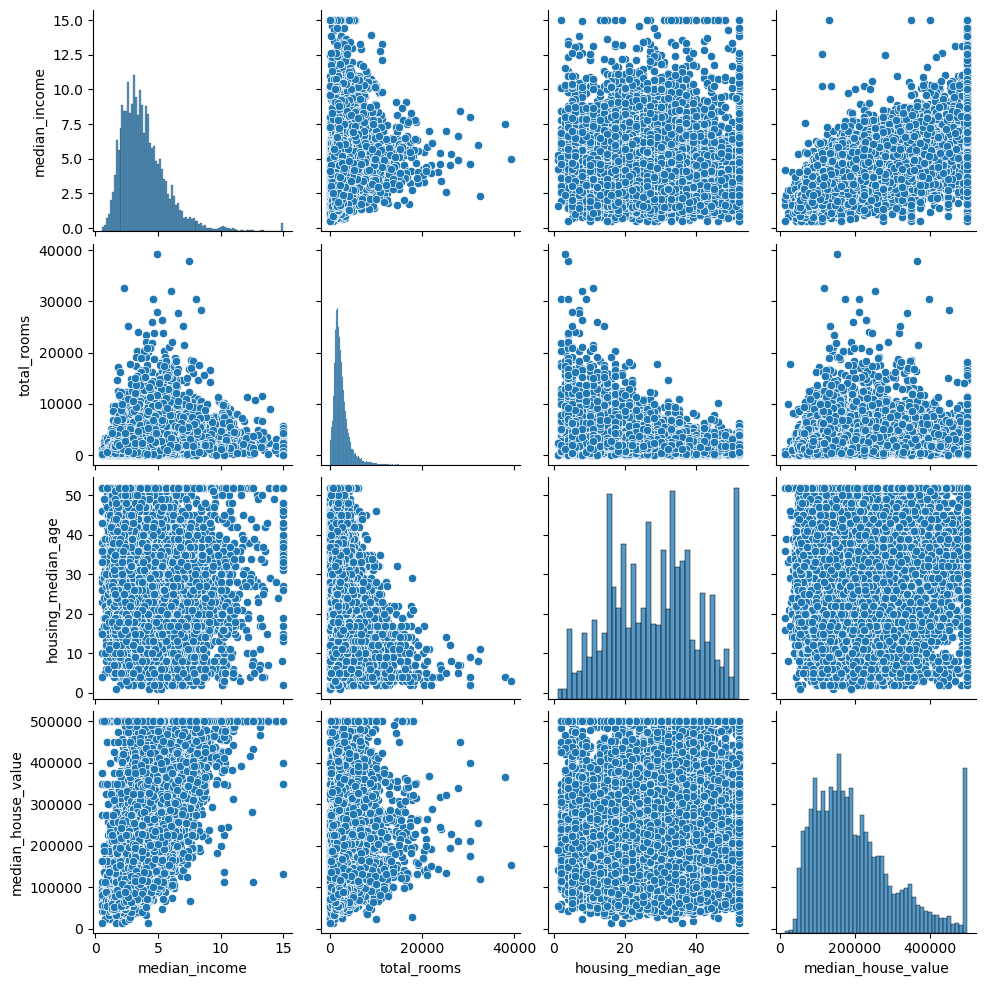

In [25]:
# Pair plot for selected features
sns.pairplot(df[['median_income', 'total_rooms', 'housing_median_age', 'median_house_value']])
plt.show()

In [29]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [30]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [32]:
X = df[['median_income', 'total_rooms', 'longitude', 'latitude']]  
y = df['median_house_value']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
# Use only one feature, e.g., median_income
X_simple = df[['median_income']]
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train_simple)

y_pred_simple = model_simple.predict(X_test_simple)


In [35]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)


In [36]:
# Function to evaluate
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2

# Evaluate both models
print("Simple Linear Regression:")
print(evaluate(y_test_simple, y_pred_simple))

print("\nMultiple Linear Regression:")
print(evaluate(y_test, y_pred_multi))

Simple Linear Regression:
(7091157771.76555, 84209.01241414454, 0.45885918903846656)

Multiple Linear Regression:
(5601544311.675958, 74843.46539061348, 0.5725346510373044)


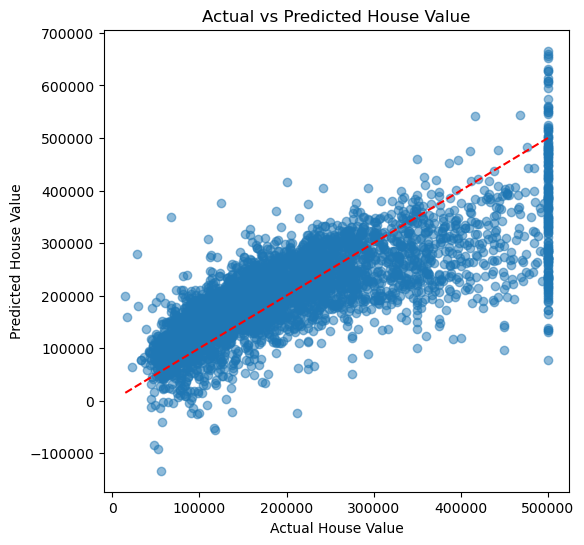

In [37]:
# Plotting actual vs predicted (Multiple Regression)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_multi, alpha=0.5)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Value")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect prediction
plt.show()